Data Loader

In [ ]:
# import pandas as pd
# import ast

# def process_pcl_data(full_data_path, train_data_path, output_path):
#     """
#     Merges the PCL TSV and CSV files, transforms the labels into a binary target,
#     and saves the result.
#     """
#     print(f"Starting processing: {full_data_path} + {train_data_path}")

#     # 1. Load the TSV file (The 'Full' dataset)
#     # Based on the Don't Patronize Me! dataset structure
#     columns_full = ['par_id', 'semeval_id', 'keyword', 'country_code', 'text', 'original_label']
#     df_full = pd.read_csv(full_data_path, sep="\t", header=None, names=columns_full, engine="python")

#     df_full["par_id"] = pd.to_numeric(df_full["par_id"], errors="coerce")
#     df_full = df_full.dropna(subset=["par_id"]).copy()
#     df_full["par_id"] = df_full["par_id"].astype(int)


#     # 2. Load the CSV file (The 'Labels' dataset)
#     df_labels = pd.read_csv(train_data_path)

#     # 3. Data Cleaning: Ensure par_id is the same type in both (Integer)
#     # This prevents merge failures if one is read as a string and the other as an int
#     df_full['par_id'] = pd.to_numeric(df_full['par_id'], errors='coerce')
#     df_labels['par_id'] = pd.to_numeric(df_labels['par_id'], errors='coerce')

#     # 4. Merge the datasets
#     # Using 'inner' or 'right' ensures we only keep rows we actually have labels for
#     df_merged = pd.merge(df_full, df_labels, on='par_id', how='right')

#     # 5. Define logic for the binary label
#     def check_for_pcl(label_str):
#         if pd.isna(label_str):
#             return 0
#         try:
#             # Safely evaluate the string representation of a list (e.g., "[0, 1, 0]")
#             categories = ast.literal_eval(str(label_str))
#             # Return 1 if there is at least one '1' in the list (positive for PCL)
#             return 1 if 1 in categories else 0
#         except (ValueError, SyntaxError):
#             # Fallback if the label isn't a list-string
#             return 0

#     # 6. Apply transformation
#     df_merged['final_label'] = df_merged['label'].apply(check_for_pcl)

#     # 7. Clean up columns
#     # We remove 'original_label' and the raw 'label' list to keep things tidy
#     cols_to_drop = [c for c in ['original_label', 'label'] if c in df_merged.columns]
#     df_merged = df_merged.drop(columns=cols_to_drop)

#     # 8. Save the data
#     df_merged.to_csv(output_path, index=False)

#     print(f"Success! Saved {len(df_merged)} rows to {output_path}")
#     print(df_merged[['par_id', 'keyword', 'final_label']].head())

#     return df_merged

# if __name__ == "__main__":
#     df1 = process_pcl_data(
#         full_data_path='original_data/full_data.tsv',
#         train_data_path='original_data/train_data_raw.csv',
#         output_path='train_data.csv'
#     )

#     df2 = process_pcl_data(
#         full_data_path='original_data/full_data.tsv',
#         train_data_path='original_data/test_data_raw.csv',
#         output_path='test_data.csv'
#     )

#     df = pd.concat([df1, df2], ignore_index=True)

#     df.to_csv('all_data.csv', index=False)

Starting processing: original_data/full_data.tsv + original_data/train_data_raw.csv
Success! Saved 8375 rows to train_data.csv
   par_id        keyword  final_label
0    4341  poor-families            1
1    4136       homeless            1
2   10352  poor-families            1
3    8279     vulnerable            1
4    1164  poor-families            1
Starting processing: original_data/full_data.tsv + original_data/test_data_raw.csv
Success! Saved 2094 rows to test_data.csv
   par_id   keyword  final_label
0    4046  hopeless            1
1    1279   refugee            1
2    8330   refugee            1
3    4063   in-need            1
4    4089  homeless            1


In [1]:
import pandas as pd
import ast

def process_pcl_data(full_data_path, split_labels_path, output_path):
    print(f"Starting processing: {full_data_path} + {split_labels_path}")

    columns_full = ["par_id", "semeval_id", "keyword", "country_code", "text", "original_label"]
    df_full = pd.read_csv(full_data_path, sep="\t", header=None, names=columns_full, engine="python")

    # Make IDs numeric, but DO NOT drop any rows
    df_full["par_id"] = pd.to_numeric(df_full["par_id"], errors="coerce")

    df_labels = pd.read_csv(split_labels_path)
    df_labels["par_id"] = pd.to_numeric(df_labels["par_id"], errors="coerce")

    # IMPORTANT: keep ALL rows from df_labels (the split file)
    df_merged = pd.merge(df_labels, df_full, on="par_id", how="left")

    # --- Diagnose missing/empty text after merge (but keep rows) ---
    missing_text = df_merged["text"].isna().sum()
    empty_text = (df_merged["text"].fillna("").astype(str).str.strip() == "").sum()

    print(f"Rows in split file: {len(df_labels)}")
    print(f"Rows after merge:  {len(df_merged)} (should match split file)")
    print(f"Missing text (NaN) after merge: {missing_text}")
    print(f"Empty text ('') after merge:    {empty_text}")

    # Keep ALL rows: fill missing fields safely
    df_merged["keyword"] = df_merged.get("keyword", "").fillna("").astype(str)
    df_merged["text"] = df_merged.get("text", "").fillna("").astype(str)

    # Binary label
    def check_for_pcl(label_str):
        if pd.isna(label_str):
            return 0
        try:
            categories = ast.literal_eval(str(label_str))
            return 1 if 1 in categories else 0
        except (ValueError, SyntaxError):
            return 0

    df_merged["final_label"] = df_merged["label"].apply(check_for_pcl)

    # Drop noisy columns
    cols_to_drop = [c for c in ["original_label", "label"] if c in df_merged.columns]
    df_merged = df_merged.drop(columns=cols_to_drop)

    df_merged.to_csv(output_path, index=False)
    print(f"Saved {len(df_merged)} rows to {output_path}")

    # If you want to see the exact problematic row(s):
    bad_rows = df_merged[df_merged["text"].str.strip() == ""]
    if len(bad_rows) > 0:
        print("\nExample rows with empty text (kept):")
        print(bad_rows[["par_id", "keyword", "country_code", "final_label"]].head(5))

    return df_merged


if __name__ == "__main__":
    df_train = process_pcl_data(
        full_data_path="original_data/full_data.tsv",
        split_labels_path="original_data/train_data_raw.csv",
        output_path="train_data.csv",
    )

    df_dev = process_pcl_data(
        full_data_path="original_data/full_data.tsv",
        split_labels_path="original_data/test_data_raw.csv",
        output_path="test_data.csv",
    )

    df_all = pd.concat([df_train, df_dev], ignore_index=True)
    df_all.to_csv("all_data.csv", index=False)
    print("Saved all_data.csv with rows:", len(df_all))

Starting processing: original_data/full_data.tsv + original_data/train_data_raw.csv
Rows in split file: 8375
Rows after merge:  8375 (should match split file)
Missing text (NaN) after merge: 0
Empty text ('') after merge:    0
Saved 8375 rows to train_data.csv
Starting processing: original_data/full_data.tsv + original_data/test_data_raw.csv
Rows in split file: 2094
Rows after merge:  2094 (should match split file)
Missing text (NaN) after merge: 1
Empty text ('') after merge:    1
Saved 2094 rows to test_data.csv

Example rows with empty text (kept):
     par_id  keyword country_code  final_label
434    8640  migrant           ke            0
Saved all_data.csv with rows: 10469



===== DUPLICATE DETECTION =====

Exact Text Duplicates: 0 rows
  Unique duplicate texts: 0

Checking for duplicates with conflicting labels:

===== SPECIAL CHARACTERS & HTML DETECTION =====

HTML/Special Character Patterns Found:
  amp: 61 rows (0.58%)
  lt: 0 rows (0.00%)
  gt: 17 rows (0.16%)
  quot: 0 rows (0.00%)
  apos: 0 rows (0.00%)
  html_tags: 401 rows (3.83%)
  newlines: 0 rows (0.00%)
  tabs: 0 rows (0.00%)
  unicode_escapes: 0 rows (0.00%)

Punctuation Statistics:
  Mean punctuation density: 0.0239
  Max punctuation density: 0.2000
  Rows with >50% punctuation: 0

Non-ASCII Characters:
  Rows with non-ASCII: 0 (0.00%)

===== OUTLIER DETECTION =====

Token Count Statistics:
  Mean: 43.19
  Median: 37.00
  Std Dev: 26.01
  Min: 0
  Max: 819
  Q1 (25%): 27.00
  Q3 (75%): 53.00

Outliers (IQR method):
  Lower bound: -12.00 tokens
  Upper bound: 92.00 tokens
  Total outliers: 490 rows (4.68%)

Very Short Texts (<5 tokens): 23 rows (0.22%)
  Examples:
    'The Filipino immigrant

/tmp/ipykernel_1081/471212473.py:195: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No PCL (0)', 'PCL (1)'])


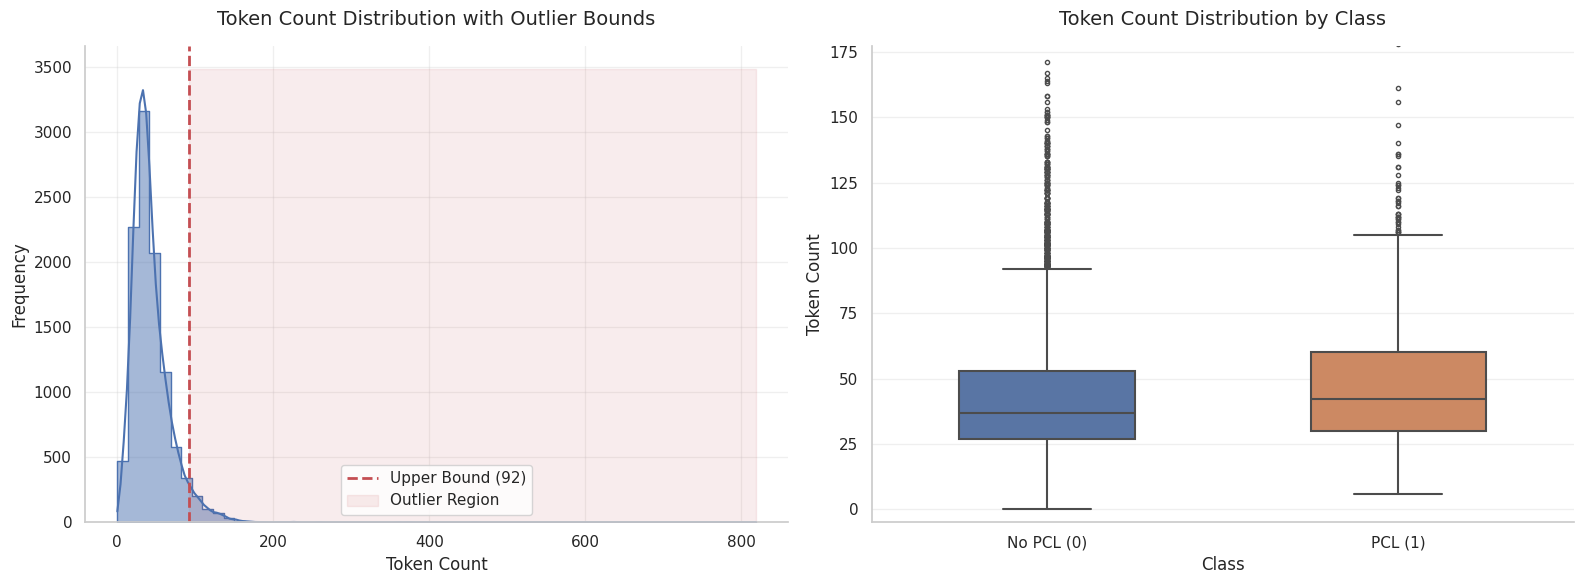


===== NOISE SUMMARY REPORT =====

Total Records: 10469

1. DUPLICATES:
   - Exact duplicates: 0

2. SPECIAL CHARACTERS/HTML:
   - Non-ASCII rows: 0
   - High punctuation (>50%): 0

3. OUTLIERS:
   - Length outliers: 490
   - Very short (<5 tokens): 23
   - Very long (>200 tokens): 9

Outliers saved to: EDA/LexicalAnalysis/outliers_detected.csv


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from pathlib import Path

# --- SETTINGS & STYLE ---
sns.set_theme(style="whitegrid")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.alpha'] = 0.3

# Define the folder name/path
folder_path = Path("EDA/LexicalAnalysis")

# Create the folder
folder_path.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv('all_data.csv')
# Ensure integer type for labels (helps with categorical plotting later)
df['y'] = (df['final_label'] == 1).astype(int)

# DUPLICATES

print("\n===== DUPLICATE DETECTION =====")

# Check for exact text duplicates
exact_duplicates = df[df.duplicated(subset=['text'], keep=False)]
num_exact_duplicates = len(exact_duplicates)
print(f"\nExact Text Duplicates: {num_exact_duplicates} rows")
print(f"  Unique duplicate texts: {df['text'].duplicated().sum()}")

if num_exact_duplicates > 0:
    print("\nSample duplicate texts:")
    dup_texts = df['text'].value_counts()
    dup_texts = dup_texts[dup_texts > 1]
    for text, count in dup_texts.head(5).items():
        print(f"  '{text[:80]}...' appears {count} times")

# Check for near-duplicates (same text with different labels)
print("\nChecking for duplicates with conflicting labels:")
for text, group in df.groupby('text'):
    if len(group['y'].unique()) > 1:
        print(f"  Conflicting labels for: '{text[:80]}...'")
        print(f"    Labels: {group['y'].unique()}")
        break

# SPECIAL CHARACTERS & HTML

print("\n===== SPECIAL CHARACTERS & HTML DETECTION =====")

# Common HTML entities and special patterns
html_patterns = {
    'amp': r'&amp;',
    'lt': r'&lt;',
    'gt': r'&gt;',
    'quot': r'&quot;',
    'apos': r'&apos;',
    'html_tags': r'<[^>]+>',
    'newlines': r'\\n|\n',
    'tabs': r'\\t|\t',
    'unicode_escapes': r'\\u[0-9a-fA-F]{4}',
}

print("\nHTML/Special Character Patterns Found:")
for pattern_name, pattern in html_patterns.items():
    count = df['text'].str.contains(pattern, regex=True, na=False).sum()
    percentage = (count / len(df)) * 100
    print(f"  {pattern_name}: {count} rows ({percentage:.2f}%)")

    if count > 0 and count <= 5:
        print(f"    Examples:")
        examples = df[df['text'].str.contains(pattern, regex=True, na=False)]['text'].head(3)
        for ex in examples:
            print(f"      '{ex[:80]}...'")

# Check for excessive punctuation
def count_punctuation(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'[!?.,;:\-\(\)\[\]{}\"\'\/\\@#$%^&*+=]', text))

df['punctuation_count'] = df['text'].apply(count_punctuation)
df['punctuation_density'] = df['punctuation_count'] / df['text'].str.len()

print(f"\nPunctuation Statistics:")
print(f"  Mean punctuation density: {df['punctuation_density'].mean():.4f}")
print(f"  Max punctuation density: {df['punctuation_density'].max():.4f}")
print(f"  Rows with >50% punctuation: {(df['punctuation_density'] > 0.5).sum()}")

# Check for non-ASCII characters
def has_non_ascii(text):
    if not isinstance(text, str):
        return False
    return any(ord(char) > 127 for char in text)

non_ascii_count = df['text'].apply(has_non_ascii).sum()
print(f"\nNon-ASCII Characters:")
print(f"  Rows with non-ASCII: {non_ascii_count} ({(non_ascii_count/len(df)*100):.2f}%)")

######## OUTLIERS #######

print("\n===== OUTLIER DETECTION =====")

# Text length analysis
df['text_length'] = df['text'].str.len()

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)
df['token_count'] = df['tokens'].apply(len)

print(f"\nToken Count Statistics:")
print(f"  Mean: {df['token_count'].mean():.2f}")
print(f"  Median: {df['token_count'].median():.2f}")
print(f"  Std Dev: {df['token_count'].std():.2f}")
print(f"  Min: {df['token_count'].min()}")
print(f"  Max: {df['token_count'].max()}")
print(f"  Q1 (25%): {df['token_count'].quantile(0.25):.2f}")
print(f"  Q3 (75%): {df['token_count'].quantile(0.75):.2f}")

# IQR-based outlier detection
Q1 = df['token_count'].quantile(0.25)
Q3 = df['token_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['token_count'] < lower_bound) | (df['token_count'] > upper_bound)]
print(f"\nOutliers (IQR method):")
print(f"  Lower bound: {lower_bound:.2f} tokens")
print(f"  Upper bound: {upper_bound:.2f} tokens")
print(f"  Total outliers: {len(outliers)} rows ({(len(outliers)/len(df)*100):.2f}%)")

# Short texts (< 5 tokens)
short_texts = df[df['token_count'] < 5]
print(f"\nVery Short Texts (<5 tokens): {len(short_texts)} rows ({(len(short_texts)/len(df)*100):.2f}%)")
if len(short_texts) > 0:
    print(f"  Examples:")
    for text in short_texts['text'].head(5):
        print(f"    '{text}'")

# Long texts (> 200 tokens)
long_texts = df[df['token_count'] > 200]
print(f"\nVery Long Texts (>200 tokens): {len(long_texts)} rows ({(len(long_texts)/len(df)*100):.2f}%)")
if len(long_texts) > 0:
    print(f"  Sample long text length: {long_texts['token_count'].iloc[0]} tokens")

# Class-wise outlier analysis
print(f"\nOutlier Distribution by Class:")
print(f"  Class 0 (No PCL) outliers: {len(outliers[outliers['y']==0])} / {(outliers['y']==0).sum()}")
print(f"  Class 1 (PCL) outliers: {len(outliers[outliers['y']==1])} / {(outliers['y']==1).sum()}")

# --- IMPROVED VISUALIZATIONS ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram with Outlier bounds highlighted

sns.histplot(data=df, x='token_count', bins=60, kde=True, ax=axes[0],
             color="#4C72B0", alpha=0.5, element="step")

# Highlight lower bound (if applicable/above 0) and upper bound
if lower_bound > 0:
    axes[0].axvline(lower_bound, color='#C44E52', linestyle='--', linewidth=2, label=f'Lower Bound ({lower_bound:.0f})')
axes[0].axvline(upper_bound, color='#C44E52', linestyle='--', linewidth=2, label=f'Upper Bound ({upper_bound:.0f})')

# Shade the upper outlier region
y_min, y_max = axes[0].get_ylim()
axes[0].fill_betweenx([y_min, y_max], upper_bound, df['token_count'].max(),
                      color='#C44E52', alpha=0.1, label='Outlier Region')

axes[0].set_xlabel('Token Count', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Token Count Distribution with Outlier Bounds', fontsize=14, pad=15)
axes[0].legend()

# 2. Box plot by class

sns.boxplot(data=df, x='y', y='token_count', hue='y', ax=axes[1],
            palette={0: "#4C72B0", 1: "#DD8452"},
            width=0.5, fliersize=3, linewidth=1.5, legend=False)

axes[1].set_ylabel('Token Count', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_xticklabels(['No PCL (0)', 'PCL (1)'])
axes[1].set_title('Token Count Distribution by Class', fontsize=14, pad=15)

# Optional: Focus the y-axis to see the IQR boxes clearly if extreme outliers squash them
axes[1].set_ylim(-5, df['token_count'].quantile(0.99) + 50)

plt.tight_layout()
plt.savefig(f'{folder_path}/outlier_detection_styled.png', bbox_inches='tight')
plt.show()

######## SUMMARY REPORT #######

print("\n===== NOISE SUMMARY REPORT =====")
print(f"\nTotal Records: {len(df)}")
print(f"\n1. DUPLICATES:")
print(f"   - Exact duplicates: {df['text'].duplicated().sum()}")
print(f"\n2. SPECIAL CHARACTERS/HTML:")
print(f"   - Non-ASCII rows: {non_ascii_count}")
print(f"   - High punctuation (>50%): {(df['punctuation_density'] > 0.5).sum()}")
print(f"\n3. OUTLIERS:")
print(f"   - Length outliers: {len(outliers)}")
print(f"   - Very short (<5 tokens): {len(short_texts)}")
print(f"   - Very long (>200 tokens): {len(long_texts)}")

# Save outlier info to CSV for further inspection
if len(outliers) > 0:
    outliers_to_inspect = outliers[['text', 'token_count', 'final_label', 'y']].copy()
    outliers_to_inspect.to_csv(f'{folder_path}/outliers_detected.csv', index=False)
    print(f"\nOutliers saved to: {folder_path}/outliers_detected.csv")

Noise Artifacts


===== N-GRAM ANALYSIS =====

Top 20 Bigrams:
[(('of', 'the'), 2711), (('in', 'the'), 2460), (('to', 'the'), 1315), (('in', 'need'), 1025), (('poor', 'families'), 921), (('for', 'the'), 873), (('on', 'the'), 811), (('to', 'be'), 740), (('and', 'the'), 734), (('at', 'the'), 653), (('need', 'of'), 605), (('in', 'a'), 587), (('by', 'the'), 563), (('that', 'the'), 549), (('of', 'a'), 541), (('from', 'the'), 535), (('with', 'the'), 502), (('it', 'is'), 497), (('is', 'a'), 448), (('as', 'a'), 443)]

Top 20 Trigrams:
[(('in', 'need', 'of'), 594), (('from', 'poor', 'families'), 230), (('one', 'of', 'the'), 190), (('those', 'in', 'need'), 162), (('as', 'well', 'as'), 153), (('the', 'united', 'states'), 145), (('the', 'number', 'of'), 135), (('the', 'most', 'vulnerable'), 122), (('in', 'the', 'country'), 114), (('are', 'in', 'need'), 111), (('some', 'of', 'the'), 105), (('according', 'to', 'the'), 101), (('the', 'u', 's'), 93), (('need', 'of', 'a'), 88), (('poor', 'families', 'in'), 84), (('poor

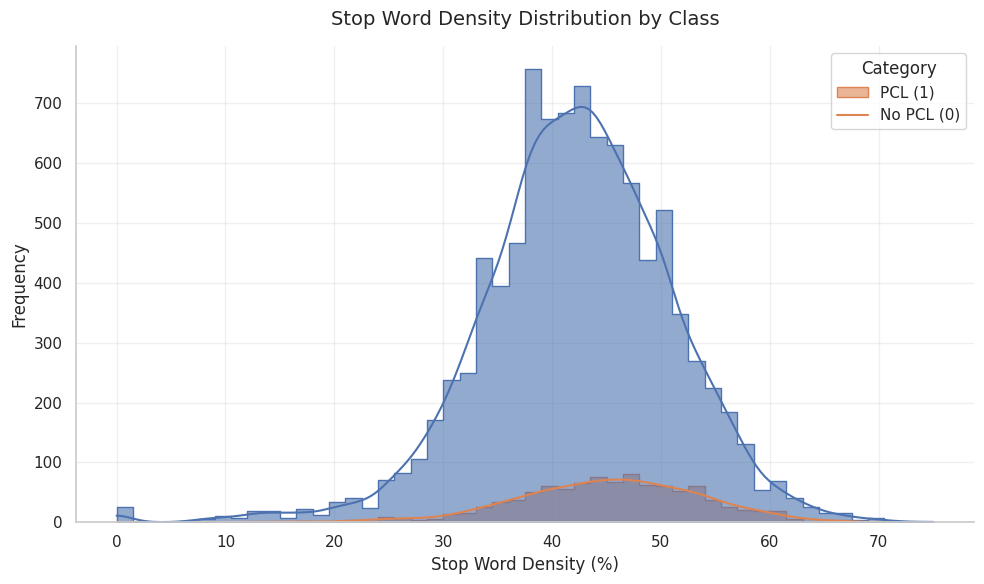


===== WORD CLOUDS & FREQUENCY =====


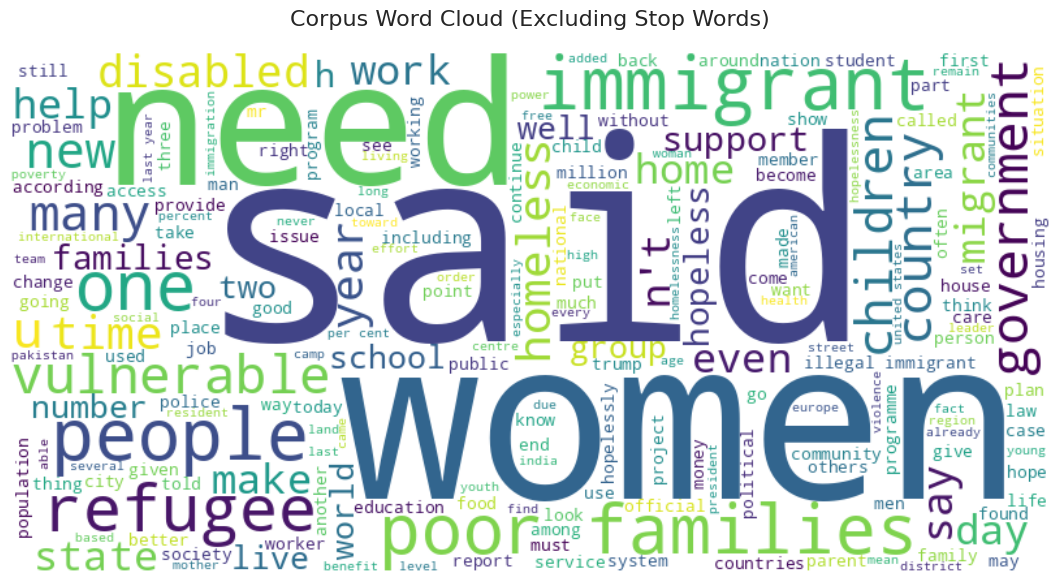

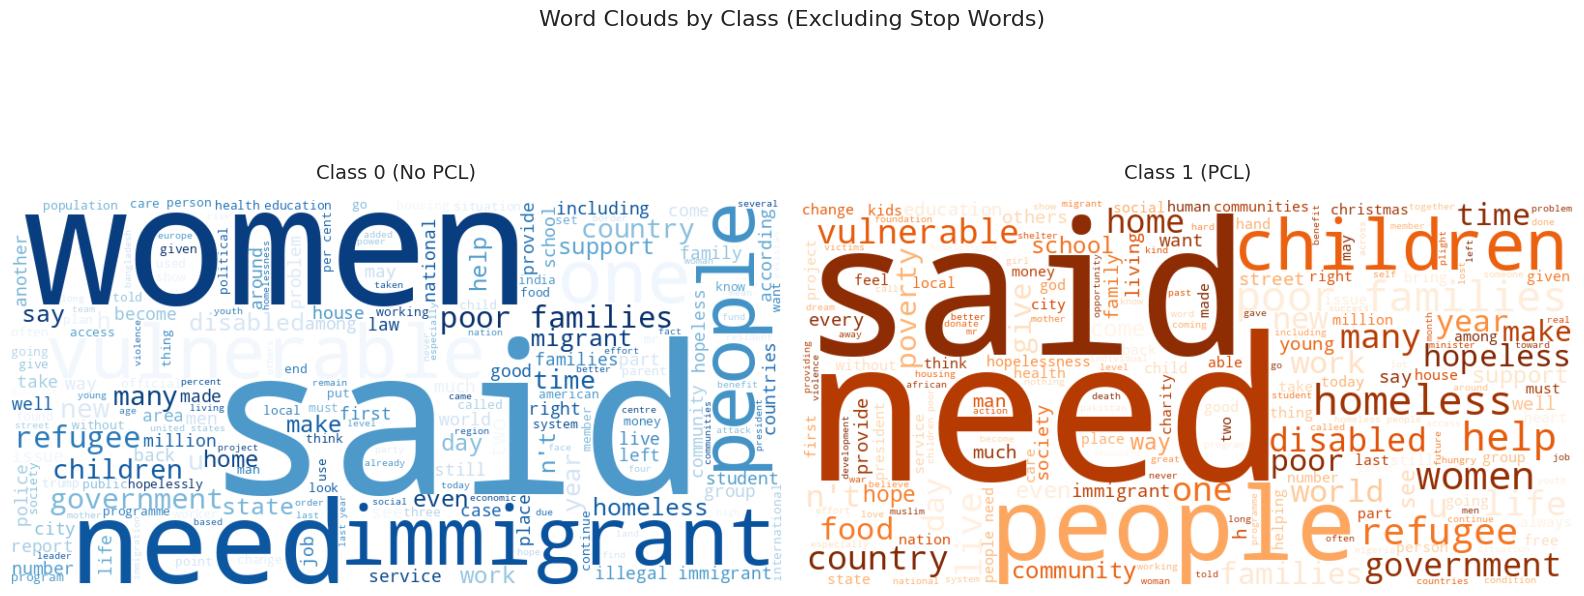

/tmp/ipykernel_1081/629261525.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(tokens_only), palette="mako", ax=ax)


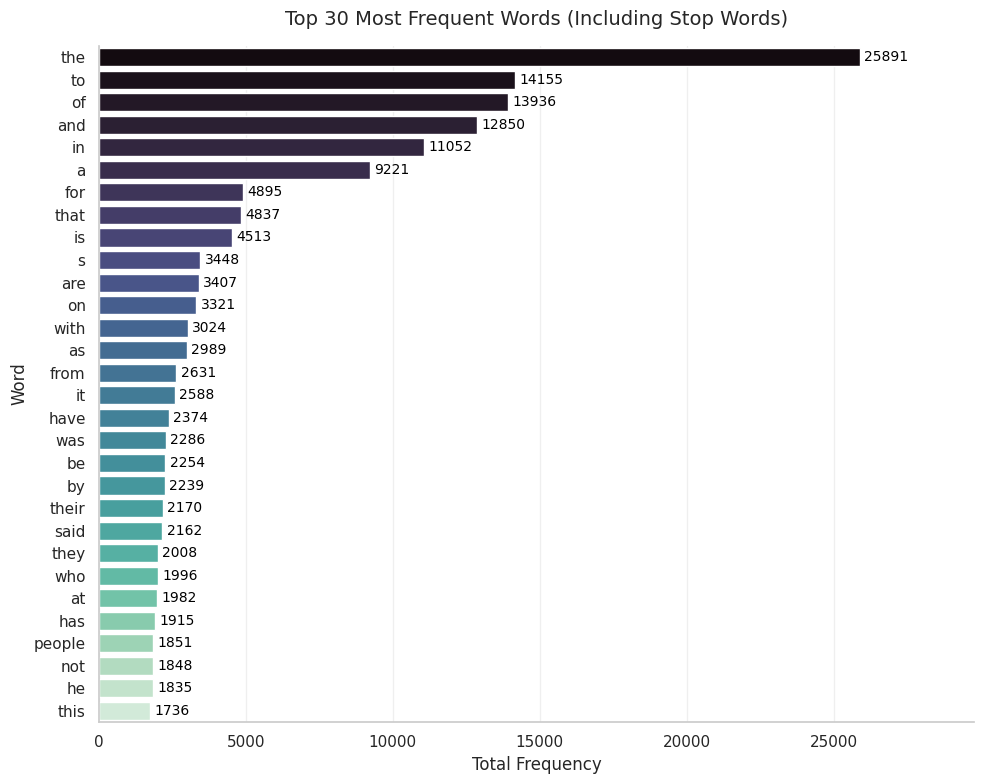


Top 30 Words (including stop words):
[('the', 25891), ('to', 14155), ('of', 13936), ('and', 12850), ('in', 11052), ('a', 9221), ('for', 4895), ('that', 4837), ('is', 4513), ('s', 3448), ('are', 3407), ('on', 3321), ('with', 3024), ('as', 2989), ('from', 2631), ('it', 2588), ('have', 2374), ('was', 2286), ('be', 2254), ('by', 2239), ('their', 2170), ('said', 2162), ('they', 2008), ('who', 1996), ('at', 1982), ('has', 1915), ('people', 1851), ('not', 1848), ('he', 1835), ('this', 1736)]

Top 30 Words (excluding stop words):
[('said', 2162), ('people', 1851), ('women', 1718), ('need', 1344), ('families', 1341), ('immigrants', 1296), ('vulnerable', 1204), ('poor', 1190), ('disabled', 1145), ('children', 1039), ('homeless', 1035), ('also', 985), ('refugees', 966), ('one', 953), ('government', 852), ('would', 818), ('new', 808), ('many', 789), ('country', 751), ('year', 747), ("n't", 687), ('us', 628), ('immigrant', 550), ('help', 540), ('h', 538), ('hopeless', 535), ('two', 524), ('time', 

In [3]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from pathlib import Path

# Download required NLTK resources
nltk.download('stopwords', quiet=True)

# --- SETTINGS & STYLE ---
sns.set_theme(style="whitegrid")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.alpha'] = 0.3

# Define the folder name/path
folder_path = Path("EDA/NoiseArtifacts")

# Create the folder
folder_path.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv('all_data.csv')
# Ensure labels are integers for categorical plotting
df['y'] = (df['final_label'] >= 1).astype(int)

# Create a column for tokenized text
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)

# Get English stop words
stop_words = set(stopwords.words('english'))

######## N-GRAM ANALYSIS #######

def get_ngrams(tokens, n):
    """Extract n-grams from token list"""
    return list(ngrams(tokens, n))

# Get all bigrams and trigrams
all_tokens = [token for tokens in df['tokens'] for token in tokens]
all_bigrams = [bigram for tokens in df['tokens'] for bigram in get_ngrams(tokens, 2)]
all_trigrams = [trigram for tokens in df['tokens'] for trigram in get_ngrams(tokens, 3)]

bigram_counts = Counter(all_bigrams)
trigram_counts = Counter(all_trigrams)

print("\n===== N-GRAM ANALYSIS =====")
print("\nTop 20 Bigrams:")
print(bigram_counts.most_common(20))

print("\nTop 20 Trigrams:")
print(trigram_counts.most_common(20))

# By class
print("\n--- Bigrams by Class ---")
class_0_bigrams = [bigram for tokens, label in zip(df['tokens'], df['y']) if label == 0
                    for bigram in get_ngrams(tokens, 2)]
class_1_bigrams = [bigram for tokens, label in zip(df['tokens'], df['y']) if label == 1
                    for bigram in get_ngrams(tokens, 2)]

class_0_bigram_counts = Counter(class_0_bigrams)
class_1_bigram_counts = Counter(class_1_bigrams)

print("\nTop 15 Bigrams (Class 0 - No PCL):")
print(class_0_bigram_counts.most_common(15))

print("\nTop 15 Bigrams (Class 1 - PCL):")
print(class_1_bigram_counts.most_common(15))

######## STOP WORD DENSITY #######

print("\n===== STOP WORD DENSITY =====")

def calculate_stop_word_density(tokens):
    """Calculate percentage of stop words in token list"""
    if len(tokens) == 0:
        return 0
    stop_word_count = sum(1 for token in tokens if token in stop_words)
    return (stop_word_count / len(tokens)) * 100

df['stop_word_density'] = df['tokens'].apply(calculate_stop_word_density)

print(f"\nOverall Stop Word Density:")
print(f"  Mean: {df['stop_word_density'].mean():.2f}%")
print(f"  Median: {df['stop_word_density'].median():.2f}%")
print(f"  Min: {df['stop_word_density'].min():.2f}%")
print(f"  Max: {df['stop_word_density'].max():.2f}%")

print(f"\nStop Word Density by Class:")
print(f"  Class 0 (No PCL) - Mean: {df[df['y']==0]['stop_word_density'].mean():.2f}%")
print(f"  Class 1 (PCL) - Mean: {df[df['y']==1]['stop_word_density'].mean():.2f}%")

# Visualize stop word density distribution

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='stop_word_density', hue='y', bins=50, kde=True,
             palette={0: "#4C72B0", 1: "#DD8452"}, alpha=0.6, element="step")

plt.xlabel('Stop Word Density (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Stop Word Density Distribution by Class', fontsize=14, pad=15)
plt.legend(title="Category", labels=["PCL (1)", "No PCL (0)"])

plt.tight_layout()
plt.savefig(f'{folder_path}/stop_word_density_styled.png')
plt.show()

######## WORD CLOUDS & FREQUENCY #######

print("\n===== WORD CLOUDS & FREQUENCY =====")

# Overall word cloud

all_text = ' '.join([token for tokens in df['tokens'] for token in tokens if token not in stop_words])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Corpus Word Cloud (Excluding Stop Words)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(f'{folder_path}/wordcloud_all_styled.png')
plt.show()

# Word cloud by class
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Class 0
class_0_text = ' '.join([token for tokens, label in zip(df['tokens'], df['y']) if label == 0
                          for token in tokens if token not in stop_words])
wordcloud_0 = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(class_0_text)
axes[0].imshow(wordcloud_0, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Class 0 (No PCL)', fontsize=14, pad=15)

# Class 1
class_1_text = ' '.join([token for tokens, label in zip(df['tokens'], df['y']) if label == 1
                          for token in tokens if token not in stop_words])
wordcloud_1 = WordCloud(width=800, height=400, background_color='white', colormap='Oranges').generate(class_1_text)
axes[1].imshow(wordcloud_1, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Class 1 (PCL)', fontsize=14, pad=15)

plt.suptitle('Word Clouds by Class (Excluding Stop Words)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(f'{folder_path}/wordcloud_by_class_styled.png', bbox_inches='tight')
plt.show()

# Word frequency (top 30)

fig, ax = plt.subplots(figsize=(10, 8))
top_30_tokens = Counter(all_tokens).most_common(30)
tokens_only, freqs = zip(*top_30_tokens)

# Modern Seaborn Horizontal Barplot
sns.barplot(x=list(freqs), y=list(tokens_only), palette="mako", ax=ax)

ax.set_xlabel('Total Frequency', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title('Top 30 Most Frequent Words (Including Stop Words)', fontsize=14, pad=15)

# Add numeric labels to the end of each bar
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width() + 150, p.get_y() + p.get_height() / 2.),
                va='center', fontsize=10, color='black')

# Expand x-axis slightly to make room for the text annotations
ax.set_xlim(0, max(freqs) * 1.15)

plt.tight_layout()
plt.savefig(f'{folder_path}/top_30_words_styled.png')
plt.show()

print("\nTop 30 Words (including stop words):")
print(Counter(all_tokens).most_common(30))

print("\nTop 30 Words (excluding stop words):")
non_stop_tokens = [token for token in all_tokens if token not in stop_words]
print(Counter(non_stop_tokens).most_common(30))

Statistical Profiling

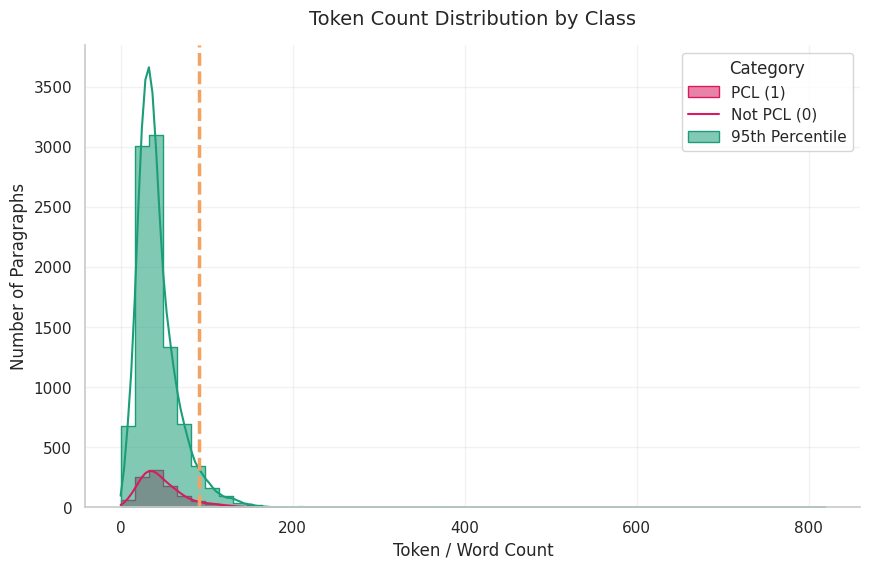

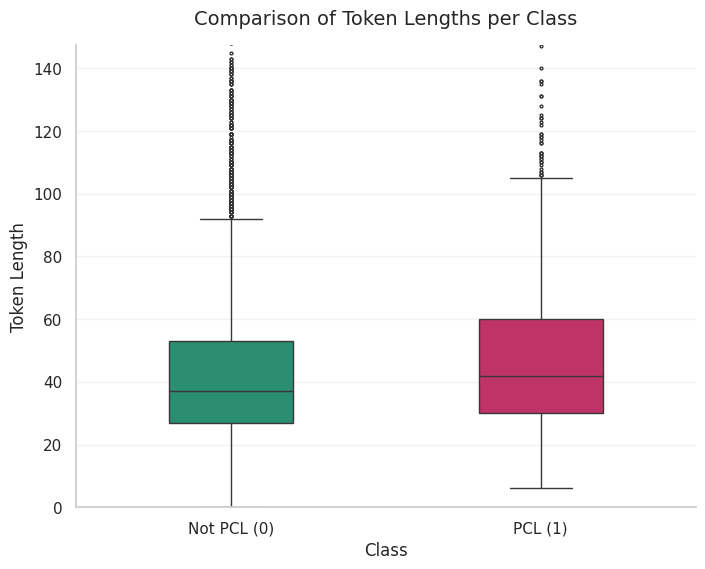

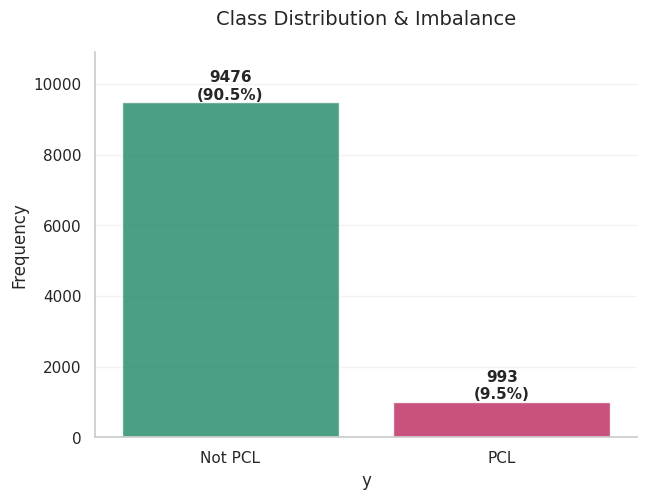


Vocabulary Size: 29091
Total Tokens: 452194

Top 20 Words: [('the', 25891), ('to', 14155), ('of', 13936), ('and', 12850), ('in', 11052), ('a', 9221), ('for', 4895), ('that', 4837), ('is', 4513), ('s', 3448), ('are', 3407), ('on', 3321), ('with', 3024), ('as', 2989), ('from', 2631), ('it', 2588), ('have', 2374), ('was', 2286), ('be', 2254), ('by', 2239)]


In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# --- SETTINGS & STYLE ---
sns.set_theme(style="whitegrid")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['grid.alpha'] = 0.25

# New Color Palette (More Distinct & Modern)
COLOR_NOT_PCL = "#1B9E77"   # Deep Teal
COLOR_PCL     = "#D81B60"   # Vibrant Magenta
COLOR_ACCENT  = "#F4A261"   # Warm Gold Accent

palette = {0: COLOR_NOT_PCL, 1: COLOR_PCL}

path = "EDA/Statistical_Profiling_Diagrams"
folder_path = Path(path)
folder_path.mkdir(parents=True, exist_ok=True)

# --- DATA PREPARATION ---
df = pd.read_csv('all_data.csv')
df['y'] = df['final_label'].astype(int)

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")
def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)
df['length'] = df['tokens'].apply(len)

token_stats = {
    "mean_length": df["length"].mean(),
    "median_length": df["length"].median(),
    "p95_length": df["length"].quantile(0.95)
}

# --- VISUALIZATION 1: TOKEN COUNT DISTRIBUTION ---

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="length",
    hue="y",
    bins=50,
    kde=True,
    palette=palette,
    alpha=0.55,
    element="step"
)

p95 = token_stats["p95_length"]
plt.axvline(
    p95,
    color=COLOR_ACCENT,
    linestyle='--',
    linewidth=2.5,
    label=f'95th Percentile ({p95:.0f} tokens)'
)

plt.xlabel("Token / Word Count")
plt.ylabel("Number of Paragraphs")
plt.title("Token Count Distribution by Class", fontsize=14, pad=15)

plt.legend(
    title="Category",
    labels=["PCL (1)", "Not PCL (0)", "95th Percentile"]
)

plt.savefig(f"{path}/length_distribution_styled.png", bbox_inches='tight')
plt.show()


# --- VISUALIZATION 2: LENGTH BY CLASS (BOXPLOT) ---

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="y",
    y="length",
    hue="y",
    palette=palette,
    width=0.4,
    fliersize=2,
    legend=False
)

plt.title("Comparison of Token Lengths per Class", fontsize=14, pad=15)
plt.xticks([0, 1], ["Not PCL (0)", "PCL (1)"])
plt.xlabel("Class")
plt.ylabel("Token Length")
plt.ylim(0, df["length"].quantile(0.99) + 20)

plt.savefig(f"{path}/length_boxplot_styled.png", bbox_inches='tight')
plt.show()


# --- VISUALIZATION 3: CLASS DISTRIBUTION BAR ---

plt.figure(figsize=(7, 5))

class_counts = df["y"].value_counts().sort_index()
total = len(df)

ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette=palette,
    alpha=0.85,
    legend=False
)

for i, p in enumerate(ax.patches):
    count = class_counts.values[i]
    percentage = (count / total) * 100
    ax.annotate(
        f'{int(count)}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=11,
        xytext=(0, 12),
        textcoords='offset points',
        fontweight='bold'
    )

plt.title("Class Distribution & Imbalance", fontsize=14, pad=20)
plt.xticks([0, 1], ["Not PCL", "PCL"])
plt.ylabel("Frequency")
plt.ylim(0, max(class_counts.values) * 1.15)

plt.savefig(f"{path}/class_distribution_styled.png", bbox_inches='tight')
plt.show()


# --- TEXTUAL SUMMARY ---
all_tokens = [token for tokens in df['tokens'] for token in tokens]
print(f"\nVocabulary Size: {len(set(all_tokens))}")
print(f"Total Tokens: {len(all_tokens)}")
print("\nTop 20 Words:", Counter(all_tokens).most_common(20))

In [5]:
!pip -q install transformers accelerate scikit-learn

In [6]:
import pandas as pd
from pathlib import Path

data_dir = Path("/content/original_data")
train_path = data_dir / "train_data_raw.csv"
test_path  = data_dir / "test_data_raw.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("TRAIN columns:", list(train_df.columns))
print("TEST columns: ", list(test_df.columns))
train_df.head(2)

TRAIN columns: ['par_id', 'label']
TEST columns:  ['par_id', 'label']


,par_id,label
0,4341,"[1, 0, 0, 1, 0, 0, 0]"
1,4136,"[0, 1, 0, 0, 0, 0, 0]"


In [7]:
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

# ============================================================
# 1) Paths (Colab)
# ============================================================
data_dir = Path("/content/")

all_data_path  = data_dir / "all_data.csv"
train_ids_path = data_dir / "original_data/train_data_raw.csv"   # contains par_id column
dev_ids_path   = data_dir / "original_data/test_data_raw.csv"    # contains par_id column (official dev split)

base_dir = Path("/content/pcl_roberta_project_2")
custom_cache_path = base_dir / "hf_cache"
output_dir = base_dir / "checkpoints"
logging_dir = base_dir / "logs"
model_save_path = base_dir / "best_pcl_model"

for p in [custom_cache_path, output_dir, logging_dir, model_save_path]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {data_dir}")
print(f"Saving to: {base_dir}")

# ============================================================
# 2) Load all_data.csv and build official train/dev from par_id
# ============================================================
all_df = pd.read_csv(all_data_path)

# sanity checks
needed = {"par_id", "keyword", "text", "final_label"}
missing = needed - set(all_df.columns)
if missing:
    raise ValueError(f"all_data.csv missing columns: {missing}. Found: {list(all_df.columns)}")

train_ids = set(pd.read_csv(train_ids_path)["par_id"].astype(int).tolist())
dev_ids   = set(pd.read_csv(dev_ids_path)["par_id"].astype(int).tolist())

train_df = all_df[all_df["par_id"].isin(train_ids)].copy()
dev_df   = all_df[all_df["par_id"].isin(dev_ids)].copy()

# Clean / types
for df in [train_df, dev_df]:
    df["keyword"] = df["keyword"].fillna("").astype(str)
    df["text"] = df["text"].fillna("").astype(str)
    df["final_label"] = df["final_label"].astype(int)

print("Train shape:", train_df.shape, " PCL rate:", train_df["final_label"].mean())
print("Dev shape:  ", dev_df.shape,   " PCL rate:", dev_df["final_label"].mean())

# ============================================================
# 3) Tokenizer + keyword injection
# ============================================================
tokenizer = RobertaTokenizer.from_pretrained("roberta-base", cache_dir=str(custom_cache_path))
sep_token = tokenizer.sep_token  # </s>

train_df["input_text"] = train_df["keyword"] + f" {sep_token} " + train_df["text"]
dev_df["input_text"]   = dev_df["keyword"]   + f" {sep_token} " + dev_df["text"]

MAX_LEN = 128

def tokenize(texts: pd.Series):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )

train_enc = tokenize(train_df["input_text"])
dev_enc   = tokenize(dev_df["input_text"])

# ============================================================
# 4) Dataset
# ============================================================
class PCLDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = PCLDataset(train_enc, train_df["final_label"].values)
dev_dataset   = PCLDataset(dev_enc,   dev_df["final_label"].values)

# ============================================================
# 5) Class weights for imbalance
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

labels_array = train_df["final_label"].values
computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_array),
    y=labels_array,
)
class_weights = torch.tensor(computed_weights, dtype=torch.float).to(device)
print("Class weights [0,1]:", class_weights.tolist())

# ============================================================
# 6) Weighted Trainer
# ============================================================
class PCLWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {"f1": f1_score(labels, preds, average="binary")}

training_args = TrainingArguments(
    output_dir=str(output_dir),
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir=str(logging_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none",
)

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
    cache_dir=str(custom_cache_path),
).to(device)

trainer = PCLWeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting training...")
trainer.train()

# ============================================================
# 7) Threshold tuning on DEV (not test!)
# ============================================================
print("Tuning probability threshold on dev set...")
preds = trainer.predict(dev_dataset)

logits = torch.tensor(preds.predictions)
probs = F.softmax(logits, dim=-1)[:, 1].numpy()
y_true = dev_df["final_label"].values

best_threshold, best_f1 = 0.5, 0.0
for t in np.arange(0.1, 0.9, 0.01):
    y_pred = (probs >= t).astype(int)
    f1 = f1_score(y_true, y_pred, average="binary")
    if f1 > best_f1:
        best_f1, best_threshold = f1, float(t)

print(f"Best threshold: {best_threshold:.2f} | Best dev F1: {best_f1:.4f}")
y_pred_final = (probs >= best_threshold).astype(int)
print(classification_report(y_true, y_pred_final))

# ============================================================
# 8) Save model + tokenizer
# ============================================================
trainer.save_model(str(model_save_path))
tokenizer.save_pretrained(str(model_save_path))
print("Saved to:", model_save_path)

Data directory: /content
Saving to: /content/pcl_roberta_project_2
Train shape: (8375, 6)  PCL rate: 0.09480597014925374
Dev shape:   (2094, 6)  PCL rate: 0.09503342884431709


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Tuning probability threshold on dev set...


Best threshold: 0.13 | Best dev F1: 0.6119
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1895
           1       0.61      0.62      0.61       199

    accuracy                           0.93      2094
   macro avg       0.78      0.79      0.79      2094
weighted avg       0.93      0.93      0.93      2094



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/pcl_roberta_project_2/best_pcl_model


In [ ]:
import torch
import pandas as pd
import torch.nn.functional as F
from pathlib import Path
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from sklearn.metrics import f1_score, classification_report

# =====================================================================
# 1. Setup Paths
# =====================================================================
model_save_path = Path("/content/BestModel/best_pcl_model")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Loading model from {model_save_path}")
print(f"Using device: {device}")

# =====================================================================
# 2. Load Trained Model and Tokenizer
# =====================================================================
tokenizer = RobertaTokenizer.from_pretrained(str(model_save_path))
model = RobertaForSequenceClassification.from_pretrained(str(model_save_path)).to(device)
model.eval()

print("Model and tokenizer loaded successfully")

# =====================================================================
# 3. Load test data (test_data.csv)
# =====================================================================
test_df = pd.read_csv("test_data.csv")
print(f"Loaded {len(test_df)} test samples from test_data.csv")

# Prepare text with keyword context
test_df['keyword'] = test_df['keyword'].fillna('').astype(str)
test_df['text'] = test_df['text'].astype(str)

# =====================================================================
# 4. Prepare input texts with keyword context (same as training)
# =====================================================================
sep_token = tokenizer.sep_token
test_df['combined_text'] = test_df['keyword'] + f" {sep_token} " + test_df['text']

MAX_LEN = 128

# =====================================================================
# 5. Tokenize and make predictions
# =====================================================================
predictions = []

print("\nMaking predictions...")
for idx, row in test_df.iterrows():
    if (idx + 1) % 500 == 0:
        print(f" Processed {idx + 1}/{len(test_df)}")

    # Tokenize single text
    encodings = tokenizer(
        row['combined_text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    # Move to device
    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    # Get model predictions
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1)
        pred_class = torch.argmax(probs, dim=-1).item()

    predictions.append(pred_class)

print(f"\nPrediction distribution:")
print(f" Class 0: {predictions.count(0)}")
print(f" Class 1: {predictions.count(1)}")

# =====================================================================
# 6. Evaluate on test_data.csv (we have labels)
# =====================================================================
print(f"\n{'='*70}")
print("EVALUATION ON TEST DATA")
print(f"{'='*70}")

labels = test_df['final_label'].values
f1 = f1_score(labels, predictions, average='binary')
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(labels, predictions, target_names=['Class 0', 'Class 1']))

# =====================================================================
# 7. Save predictions to CSV
# =====================================================================
output_df = pd.DataFrame({'prediction': predictions})

output_path = "dev.txt"
output_df.to_csv(output_path, index=False, header=False)
print(f"\nPredictions saved to {output_path}")
print(f"Output shape: {output_df.shape}")

Loading model from /content/BestModel/best_pcl_model
Using device: cuda


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model and tokenizer loaded successfully
Loaded 2094 test samples from test_data.csv

Making predictions...
 Processed 500/2094
 Processed 1000/2094
 Processed 1500/2094
 Processed 2000/2094

Prediction distribution:
 Class 0: 1896
 Class 1: 198

EVALUATION ON TEST DATA
F1 Score: 0.5894

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.96      0.96      0.96      1895
     Class 1       0.59      0.59      0.59       199

    accuracy                           0.92      2094
   macro avg       0.77      0.77      0.77      2094
weighted avg       0.92      0.92      0.92      2094


Predictions saved to dev.txt
Output shape: (2094, 1)


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# =====================================================================
# 1. Directory Setup
# =====================================================================
base_dir = Path("/content/BestModel")
base_dir.mkdir(parents=True, exist_ok=True)

custom_cache_path = base_dir / "hf_cache"
output_dir = base_dir / "checkpoints"
logging_dir = base_dir / "logs"
model_save_path = base_dir / "retrained_best_potential_model"

print(f"All models and caches will be saved to: {base_dir}")

# =====================================================================
# 2. Load and Clean Data
# =====================================================================
train_df = pd.read_csv("all_data.csv")
test_df = pd.read_csv("test_data.csv")

train_df['keyword'] = train_df['keyword'].fillna('').astype(str)
test_df['keyword'] = test_df['keyword'].fillna('').astype(str)
train_df['text'] = train_df['text'].astype(str)
test_df['text'] = test_df['text'].astype(str)

# =====================================================================
# 3. Tokenizer Setup & Context Injection
# =====================================================================
tokenizer = RobertaTokenizer.from_pretrained('roberta-base', cache_dir=str(custom_cache_path))
sep_token = tokenizer.sep_token

train_df['combined_text'] = train_df['keyword'] + f" {sep_token} " + train_df['text']
test_df['combined_text'] = test_df['keyword'] + f" {sep_token} " + test_df['text']

MAX_LEN = 128

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

train_encodings = tokenize_data(train_df['combined_text'])
test_encodings = tokenize_data(test_df['combined_text'])

# =====================================================================
# 4. Dataset & Imbalance
# =====================================================================
class PCLDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = PCLDataset(train_encodings, train_df['final_label'].values)
test_dataset = PCLDataset(test_encodings, test_df['final_label'].values)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
labels_array = train_df['final_label'].values
computed_weights = compute_class_weight('balanced', classes=np.unique(labels_array), y=labels_array)
class_weights = torch.tensor(computed_weights, dtype=torch.float).to(device)

# =====================================================================
# 6. Custom Trainer
# =====================================================================
class PCLWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {'f1': f1_score(labels, preds, average='binary')}

training_args = TrainingArguments(
    output_dir=str(output_dir),
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2, cache_dir=str(custom_cache_path))

trainer = PCLWeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting training...")
trainer.train()

# Final Evaluation and Tuning
print("Evaluating and tuning...")
preds_output = trainer.predict(test_dataset)
logits = torch.tensor(preds_output.predictions)
probs = F.softmax(logits, dim=-1)[:, 1].numpy()
y_true = test_df['final_label'].values

best_threshold, best_f1 = 0.5, 0.0
for t in np.arange(0.1, 0.9, 0.01):
    f1 = f1_score(y_true, (probs >= t).astype(int), average='binary')
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"Best Dev F1: {best_f1:.4f} at threshold {best_threshold:.2f}")

trainer.save_model(str(model_save_path))
tokenizer.save_pretrained(str(model_save_path))
print(f"Model and tokenizer saved to {model_save_path}")

All models and caches will be saved to: /content/BestModel


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting training...


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
import torch
import pandas as pd
from pathlib import Path
from transformers import RobertaTokenizer, RobertaForSequenceClassification

model_path = Path("/content/BestModel/retrained_best_potential_model")
test_file = "task4_test.tsv"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = RobertaTokenizer.from_pretrained(model_path)
model = RobertaForSequenceClassification.from_pretrained(model_path).to(device)
model.eval()

# ---- robust TSV load (NO header in file) ----
df_test = pd.read_csv(
    test_file,
    sep="\t",
    header=None,
    engine="python",
    names=["par_id", "keyword", "country_code", "text"]  # common SemEval format
)

print("Loaded rows:", len(df_test))
print("Columns:", df_test.columns.tolist())

# Prepare input
sep_token = tokenizer.sep_token
df_test["keyword"] = df_test["keyword"].fillna("").astype(str)
df_test["text"] = df_test["text"].fillna("").astype(str)
df_test["input_text"] = df_test["keyword"] + f" {sep_token} " + df_test["text"]

# Inference
predictions = []
MAX_LEN = 128

with torch.no_grad():
    for i, s in enumerate(df_test["input_text"].tolist()):
        enc = tokenizer(
            s,
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        logits = model(**enc).logits
        pred = torch.argmax(logits, dim=-1).item()
        predictions.append(pred)

        if (i + 1) % 500 == 0:
            print(f"Processed {i+1}/{len(df_test)}")

# Save exactly one label per line
with open("test.txt", "w") as f:
    f.write("\n".join(map(str, predictions)))

print("Saved test.txt with lines:", len(predictions))
print("Distribution:", predictions.count(0), predictions.count(1))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded rows: 3832
Columns: ['par_id', 'keyword', 'country_code', 'text']
Processed 500/3832
Processed 1000/3832
Processed 1500/3832
Processed 2000/3832
Processed 2500/3832
Processed 3000/3832
Processed 3500/3832
Saved test.txt with lines: 3832
Distribution: 3556 276


Epoch,Training Loss,Validation Loss


Dev F1: 0.6044444444444445


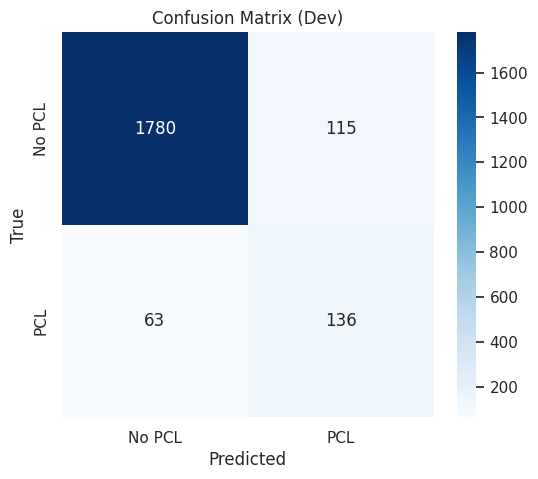


Classification Report (Dev):

              precision    recall  f1-score   support

      No PCL       0.97      0.94      0.95      1895
         PCL       0.54      0.68      0.60       199

    accuracy                           0.91      2094
   macro avg       0.75      0.81      0.78      2094
weighted avg       0.93      0.91      0.92      2094



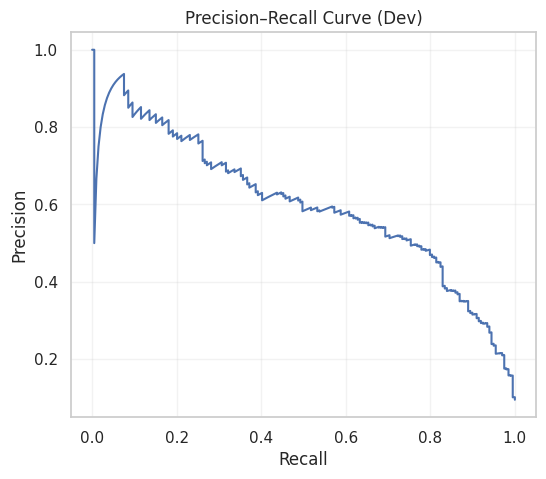

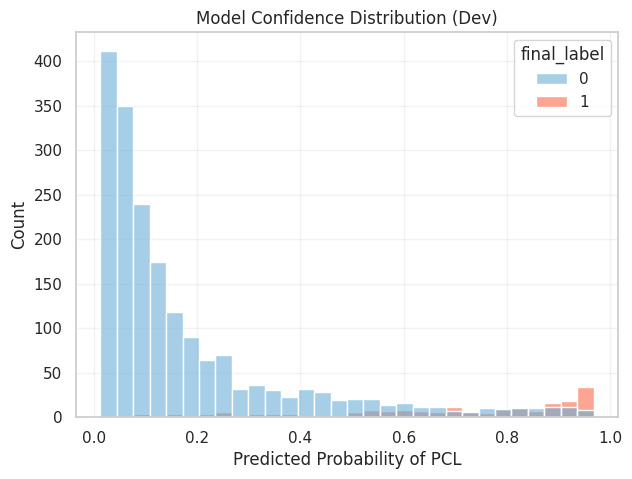


Error breakdown:
False Positives: 115
False Negatives: 63
True Positives:  136

----- FALSE POSITIVES (showing up to 5) -----

Keyword: in-need
True: 0  Pred: 1  Prob: 0.79
TEXT: In an article posted to its English language website on Thursday , China 's state-run Xinhua news agency sang the praises of microblogs , saying that China 's some 195 million microbloggers have " become strong force to help those in need . "

Keyword: homeless
True: 0  Pred: 1  Prob: 0.696
TEXT: " The proceeds from Lady Lucan 's estate will help Shelter to continue fighting bad housing and homelessness . "

Keyword: women
True: 0  Pred: 1  Prob: 0.786
TEXT: Rohani lauded the event , saying that the fest , themed " To Honour , Empower and Respect " , would empower women in many aspects including culture , social and economic standing .

Keyword: hopeless
True: 0  Pred: 1  Prob: 0.746
TEXT: In addition , it gives the usually " dark " topic a bracingly illuminating spin , as it urges viewers to value life , and

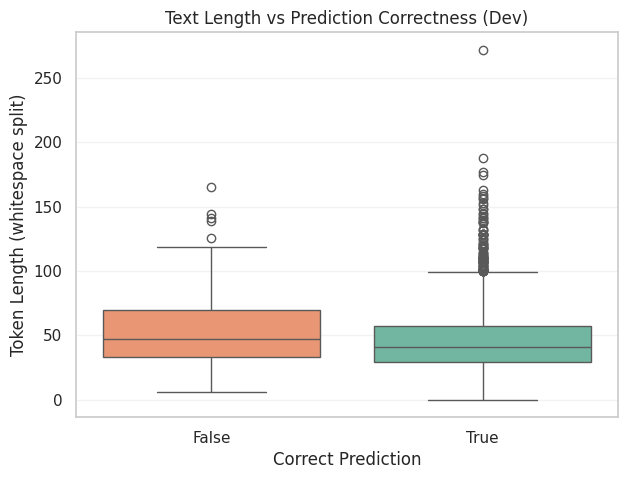


Keywords with highest error rates (top 10):
keyword
hopeless         0.142857
poor-families    0.136842
in-need          0.132743
homeless         0.122642
vulnerable       0.100478
women            0.060086
refugee          0.058511
disabled         0.056701
immigrant        0.022936
migrant          0.014493
dtype: float64


/tmp/ipykernel_1458/948202456.py:138: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["pred"] != x["final_label"]).mean())


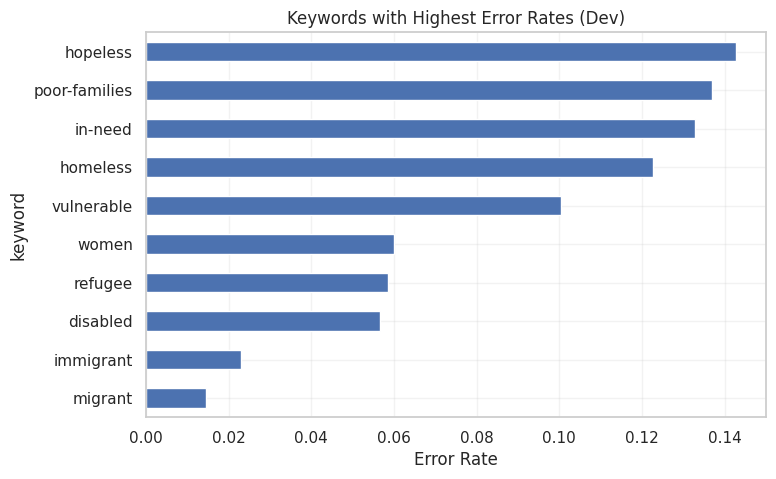


Hardest Examples (lowest confidence):
      keyword  final_label  pred  prob_pcl  confidence                                                                                                                                                                                                                                                                                                                                                                   text
     homeless            0     0  0.500111    0.000111                                  " Shelter is a basic human need and a basic human right . It is such an irony that while there are millions of homeless families , there are also thousands of government housing units standing idly and wasting away , " said Gabriela Women 's Party Rep. Arlene Brosas who personally went to the occupied area to show support .
      refugee            1     0  0.500163    0.000163    In Dublin , the Church of Ireland Archbishop Dr Michael Jackson reflected o

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    f1_score
)

sns.set_theme(style="whitegrid")

# =====================================================
# 1) Get predictions on DEV set
# =====================================================
preds = trainer.predict(dev_dataset)

logits = torch.tensor(preds.predictions)
probs = F.softmax(logits, dim=-1)[:, 1].numpy()

y_true = dev_df["final_label"].astype(int).values
y_pred = (probs >= best_threshold).astype(int)

dev_df = dev_df.copy()
dev_df["prob_pcl"] = probs
dev_df["pred"] = y_pred
dev_df["correct"] = (dev_df["pred"].astype(int) == dev_df["final_label"].astype(int))

print("Dev F1:", f1_score(y_true, y_pred, average="binary"))

# =====================================================
# 2) Confusion Matrix
# =====================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No PCL", "PCL"],
    yticklabels=["No PCL", "PCL"]
)
plt.title("Confusion Matrix (Dev)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report (Dev):\n")
print(classification_report(y_true, y_pred, target_names=["No PCL", "PCL"]))

# =====================================================
# 3) Precision-Recall Curve
# =====================================================
precision, recall, thresholds = precision_recall_curve(y_true, probs)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Dev)")
plt.show()

# =====================================================
# 4) Confidence Distribution
# =====================================================
plt.figure(figsize=(7, 5))
sns.histplot(
    data=dev_df,
    x="prob_pcl",
    hue="final_label",
    bins=30,
    palette={0: "#6baed6", 1: "#fb6a4a"},
    alpha=0.6
)
plt.title("Model Confidence Distribution (Dev)")
plt.xlabel("Predicted Probability of PCL")
plt.show()

# =====================================================
# 5) Error Categories
# =====================================================
false_positives = dev_df[(dev_df["pred"] == 1) & (dev_df["final_label"] == 0)]
false_negatives = dev_df[(dev_df["pred"] == 0) & (dev_df["final_label"] == 1)]
true_positives  = dev_df[(dev_df["pred"] == 1) & (dev_df["final_label"] == 1)]

print("\nError breakdown:")
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))
print("True Positives: ", len(true_positives))

# =====================================================
# 6) Show Example Errors (safe sampling)
# =====================================================
def show_examples(df, title, k=5):
    print(f"\n----- {title} (showing up to {k}) -----\n")
    if len(df) == 0:
        print("None.\n")
        return
    k = min(k, len(df))
    for _, row in df.sample(k, random_state=42).iterrows():
        print("Keyword:", row.get("keyword", ""))
        print("True:", int(row["final_label"]), " Pred:", int(row["pred"]), " Prob:", round(float(row["prob_pcl"]), 3))
        print("TEXT:", str(row.get("text", ""))[:400])
        print()

show_examples(false_positives, "FALSE POSITIVES")
show_examples(false_negatives, "FALSE NEGATIVES")

# =====================================================
# 7) Length vs Errors (fix palette/hue)
# =====================================================
dev_df["length"] = dev_df["text"].fillna("").astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=dev_df,
    x="correct",
    y="length",
    hue="correct",
    palette={False: "#fc8d62", True: "#66c2a5"},
    legend=False
)
plt.title("Text Length vs Prediction Correctness (Dev)")
plt.xlabel("Correct Prediction")
plt.ylabel("Token Length (whitespace split)")
plt.show()

# =====================================================
# 8) Keyword Error Analysis
# =====================================================
keyword_errors = (
    dev_df.groupby("keyword", dropna=False)
    .apply(lambda x: (x["pred"] != x["final_label"]).mean())
    .sort_values(ascending=False)
    .head(10)
)

print("\nKeywords with highest error rates (top 10):")
print(keyword_errors)

plt.figure(figsize=(8, 5))
keyword_errors.sort_values().plot(kind="barh")
plt.title("Keywords with Highest Error Rates (Dev)")
plt.xlabel("Error Rate")
plt.show()

# =====================================================
# 9) Hardest Examples (low confidence)
# =====================================================
dev_df["confidence"] = np.abs(dev_df["prob_pcl"] - 0.5)
hard_cases = dev_df.sort_values("confidence").head(10)

print("\nHardest Examples (lowest confidence):")
print(hard_cases[["keyword", "final_label", "pred", "prob_pcl", "confidence", "text"]].to_string(index=False))

In [ ]:
# Zip the BestModel folder
!zip -r Final.zip /content/Final

# Download it to your local machine
from google.colab import files
files.download("Final.zip")

updating: content/Final/ (stored 0%)
updating: content/Final/BestModel/ (stored 0%)
updating: content/Final/BestModel/best_pcl_model/ (stored 0%)
updating: content/Final/BestModel/best_pcl_model/tokenizer.json (deflated 82%)
updating: content/Final/BestModel/best_pcl_model/training_args.bin (deflated 53%)
updating: content/Final/BestModel/best_pcl_model/model.safetensors (deflated 10%)
updating: content/Final/BestModel/best_pcl_model/tokenizer_config.json (deflated 50%)
updating: content/Final/BestModel/best_pcl_model/config.json (deflated 51%)
updating: content/Final/BestModel/retrained_best_potential_model/ (stored 0%)
updating: content/Final/BestModel/retrained_best_potential_model/tokenizer.json (deflated 82%)
updating: content/Final/BestModel/retrained_best_potential_model/training_args.bin (deflated 53%)
updating: content/Final/BestModel/retrained_best_potential_model/model.safetensors (deflated 10%)
updating: content/Final/BestModel/retrained_best_potential_model/tokenizer_confi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!git config --global user.name "Rutwij Patel"
!git config --global user.email "patel.rutwij@gmail.com"

In [ ]:
!git clone https://github.com/Rutwij12/nlp-cw-final.git

Cloning into 'nlp-cw-final'...


In [ ]:
%cd nlp-cw-final

/content/nlp-cw-final


In [ ]:
!cp -r /content/Final .

In [ ]:
!git add .
!git commit -m "Add final model outputs"

[main (root-commit) d3efd37] Add final model outputs
 13 files changed, 515184 insertions(+)
 create mode 100644 Final/BestModel/best_pcl_model/config.json
 create mode 100644 Final/BestModel/best_pcl_model/model.safetensors
 create mode 100644 Final/BestModel/best_pcl_model/tokenizer.json
 create mode 100644 Final/BestModel/best_pcl_model/tokenizer_config.json
 create mode 100644 Final/BestModel/best_pcl_model/training_args.bin
 create mode 100644 Final/BestModel/retrained_best_potential_model/config.json
 create mode 100644 Final/BestModel/retrained_best_potential_model/model.safetensors
 create mode 100644 Final/BestModel/retrained_best_potential_model/tokenizer.json
 create mode 100644 Final/BestModel/retrained_best_potential_model/tokenizer_config.json
 create mode 100644 Final/BestModel/retrained_best_potential_model/training_args.bin
 create mode 100644 Final/NLP_CW (2).ipynb
 create mode 100644 Final/dev.txt
 create mode 100644 Final/test.txt


In [ ]:

!git push https://<TOKEN>@github.com/Rutwij12/nlp-cw-final.git

Enumerating objects: 16, done.
Counting objects: 100% (16/16), done.
Delta compression using up to 2 threads
Compressing objects: 100% (15/15), done.
error: RPC failed; HTTP 408 curl 22 The requested URL returned error: 408
send-pack: unexpected disconnect while reading sideband packet
Writing objects: 100% (16/16), 858.37 MiB | 11.27 MiB/s, done.
Total 16 (delta 3), reused 0 (delta 0), pack-reused 0
fatal: the remote end hung up unexpectedly
Everything up-to-date


In [ ]:
%cd /content/nlp-cw-final
!pwd
!ls -la

/content/nlp-cw-final
/content/nlp-cw-final
total 16
drwxr-xr-x 4 root root 4096 Mar  4 15:51 .
drwxr-xr-x 1 root root 4096 Mar  4 15:50 ..
drwxr-xr-x 3 root root 4096 Mar  4 15:51 Final
drwxr-xr-x 8 root root 4096 Mar  4 15:52 .git


In [ ]:
!git status
!git log --oneline -n 5


On branch main
Your branch is based on 'origin/main', but the upstream is gone.
  (use "git branch --unset-upstream" to fixup)

nothing to commit, working tree clean
d3efd37 (HEAD -> main) Add final model outputs


In [ ]:
!git remote -v

origin	https://github.com/Rutwij12/nlp-cw-final.git (fetch)
origin	https://github.com/Rutwij12/nlp-cw-final.git (push)


In [ ]:
!git branch -vv

* main d3efd37 [origin/main: gone] Add final model outputs


In [ ]:
!git push origin HEAD

fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!git remote set-url origin https://<TOKEN>@github.com/Rutwij12/nlp-cw-final.git
!git push -u origin HEAD

Enumerating objects: 16, done.
Counting objects: 100% (16/16), done.
Delta compression using up to 2 threads
Compressing objects: 100% (15/15), done.
error: RPC failed; HTTP 408 curl 22 The requested URL returned error: 408
send-pack: unexpected disconnect while reading sideband packet
Writing objects: 100% (16/16), 858.37 MiB | 11.29 MiB/s, done.
Total 16 (delta 3), reused 0 (delta 0), pack-reused 0
fatal: the remote end hung up unexpectedly
Everything up-to-date


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Zip the BestModel folder
!zip -r Final.zip /content/Final

# Download it to your local machine
from google.colab import files
files.download("Final.zip")

  adding: content/Final/ (stored 0%)
  adding: content/Final/BestModel/ (stored 0%)
  adding: content/Final/BestModel/best_pcl_model/ (stored 0%)
  adding: content/Final/BestModel/best_pcl_model/tokenizer.json (deflated 82%)
  adding: content/Final/BestModel/best_pcl_model/training_args.bin (deflated 53%)
  adding: content/Final/BestModel/best_pcl_model/model.safetensors (deflated 10%)
  adding: content/Final/BestModel/best_pcl_model/tokenizer_config.json (deflated 50%)
  adding: content/Final/BestModel/best_pcl_model/config.json (deflated 51%)
  adding: content/Final/BestModel/retrained_best_potential_model/ (stored 0%)
  adding: content/Final/BestModel/retrained_best_potential_model/tokenizer.json (deflated 82%)
  adding: content/Final/BestModel/retrained_best_potential_model/training_args.bin (deflated 53%)
  adding: content/Final/BestModel/retrained_best_potential_model/model.safetensors (deflated 10%)
  adding: content/Final/BestModel/retrained_best_potential_model/tokenizer_confi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%cd /content/nlp-cw-final
!git status

/content/nlp-cw-final
On branch main
Your branch is based on 'origin/main', but the upstream is gone.
  (use "git branch --unset-upstream" to fixup)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Final.zip

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!apt-get update -y
!apt-get install -y git-lfs
!git lfs install
!git lfs version

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,388 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:13 https://ppa.launchpadcontent.net/ubuntu

In [ ]:
!git commit -m "Configure Git LFS tracking"

On branch main
Your branch is based on 'origin/main', but the upstream is gone.
  (use "git branch --unset-upstream" to fixup)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Final.zip

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!git checkout -b fix-lfs-push
!git push -u origin fix-lfs-push

Switched to a new branch 'fix-lfs-push'
Enumerating objects: 16, done.
Counting objects: 100% (16/16), done.
Delta compression using up to 2 threads
Compressing objects: 100% (15/15), done.
error: RPC failed; HTTP 408 curl 22 The requested URL returned error: 408
send-pack: unexpected disconnect while reading sideband packet
Writing objects: 100% (16/16), 858.37 MiB | 11.53 MiB/s, done.
Total 16 (delta 3), reused 0 (delta 0), pack-reused 0
fatal: the remote end hung up unexpectedly
Everything up-to-date


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!cp -r /content/pcl_roberta_project_2/best_pcl_model/ /content/drive/MyDrive/

In [10]:
!ls /content/drive/MyDrive/best_pcl_model/

config.json	   tokenizer_config.json  training_args.bin
model.safetensors  tokenizer.json
